In [1]:
from transformers import AutoTokenizer
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

c:\Users\ASUS\Desktop\sentiment-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [12]:
DATA_PATH = Path ("../data/processed/train_df.csv")
train_df = pd.read_csv (DATA_PATH)
train_df.head()

,sentence,label,target
0,N +1 Group will pay EUR16 .5 m of the transact...,neutral,2
1,Agricultural newspaper Maaseudun Tulevaisuus h...,negative,0
2,BasWare Order Matching automatically matches p...,neutral,2
3,Investment management and investment advisory ...,neutral,2
4,3 February 2011 - Finnish broadband data commu...,positive,1


### Load FinBERT Tokenizer

In [13]:
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained (MODEL_NAME)

### Tokenizer Test and analysis

In [14]:
sample = train_df.loc[0, "sentence"]
tokens = tokenizer.tokenize (sample)
print (sample)
print (tokens)

N +1 Group will pay EUR16 .5 m of the transaction price upon closing , and the remaining sum in 2012 .
['n', '+', '1', 'group', 'will', 'pay', 'eu', '##r', '##16', '.', '5', 'm', 'of', 'the', 'transaction', 'price', 'upon', 'closing', ',', 'and', 'the', 'remaining', 'sum', 'in', '2012', '.']


In [15]:
train_df["num_tokens"] = train_df["sentence"].apply (lambda x: len(tokenizer.tokenize(x)))
train_df.head()

,sentence,label,target,num_tokens
0,N +1 Group will pay EUR16 .5 m of the transact...,neutral,2,26
1,Agricultural newspaper Maaseudun Tulevaisuus h...,negative,0,24
2,BasWare Order Matching automatically matches p...,neutral,2,15
3,Investment management and investment advisory ...,neutral,2,16
4,3 February 2011 - Finnish broadband data commu...,positive,1,56


In [16]:
train_df["num_tokens"].describe()

count    1536.000000
mean       28.561198
std        14.127162
min         2.000000
25%        18.000000
50%        26.000000
75%        36.000000
max       148.000000
Name: num_tokens, dtype: float64

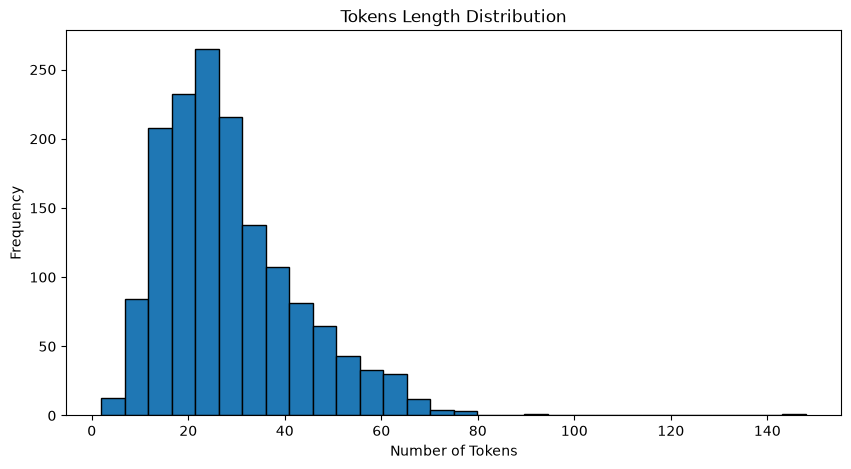

In [19]:
plt.figure (figsize=(10,5))
plt.hist (train_df["num_tokens"], bins=30, edgecolor="black")

plt.title ("Tokens Length Distribution")
plt.xlabel ("Number of Tokens")
plt.ylabel ("Frequency")

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6456\3097826709.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot (train_df["num_tokens"], vert=False)


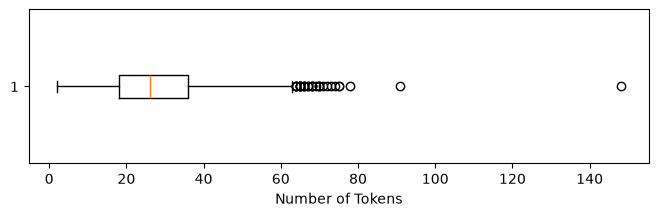

In [20]:
plt.figure (figsize=(8,2))
plt.boxplot (train_df["num_tokens"], vert=False)

plt.xlabel ("Number of Tokens")
plt.show()

In [ ]:
# Calculate token length percentiles to help choose max_length

percentiles = [90, 95, 99]
for p in percentiles:
    value = np.percentile (train_df["num_tokens"], p)
    print (f"{p}%: {value:.0f}")

90%: 48
95%: 56
99%: 68


In [22]:
train_df["num_tokens"].max()

np.int64(148)

In [23]:
train_df.loc[train_df["num_tokens"].idxmax()]

sentence      Supported Nokia phones include : N96 , N95-8GB...
label                                                   neutral
target                                                        2
num_tokens                                                  148
Name: 1426, dtype: object

In [ ]:
#count samples that exceed max_length

MAX_LENGTH = 64
num_truncated = (train_df["num_tokens"]>MAX_LENGTH).sum()
print (num_truncated)

26


In [ ]:
#Percentage of samples longer than max_length

percentage = num_truncated/len(train_df)*100
print (f"{percentage: .2f}")

 1.69


### Analysis Summary
Before fine-tuning the model, the token length distribution was analyzed to determine an appropriate `max_length`. Most sentences are relatively short, with only a small percentage exceeding 64 tokens. Therefore, `max_length=64` was selected as a balance between minimizing truncation and avoiding excessive padding leading to more efficient training.